# `08_maup`: Modifiable areal unit problem

## Introduction

### Purpose

This notebook empirically tests the sensitivity of the stage-07 metrics to the choice of spatial unit. It does not produce new substantive metric tables; its output is analytical: a set of comparisons, statistics, and visualisations that characterise how much the measured distribution of bicycle-route extent and infrastructure composition changes when the unit of analysis changes. Per thesis §3.4.6, the municipality is the headline unit of analysis and the province and H3 grid serve as the MAUP check; this notebook is the place where that check is realised.

### The two effects

The Modifiable Areal Unit Problem (MAUP) is a source of statistical bias that arises whenever spatially continuous phenomena are aggregated into discrete areal units. Because the choice of units is arbitrary, or at least not determined by the phenomenon itself, the resulting statistics can vary substantially with how space is partitioned. MAUP has two components:

**The scale effect** arises when the same boundary system is used at different resolutions. Aggregating to larger units smooths local variation, compresses the distribution, and typically raises the observed spatial autocorrelation between spatially clustered variables. The scale effect is examined by comparing metrics computed at municipality level against those computed at H3 cell level (and additionally against the province level, where N=12 makes the comparison illustrative rather than statistically powerful).

**The zoning effect** arises when units of comparable size use different boundary systems. It is examined by aggregating H3 cell metrics up to municipality level and comparing the result against the natively-computed municipality metrics. If the two approaches converge, the municipality result is robust to the choice of boundary system. Divergence reveals where administrative boundaries concentrate or dilute variation relative to the hexagonal grid.

### Why density is the focus

Bicycle route length (`bicycle_route_length_km`) is scale-dependent by construction: larger units accumulate more length, so cross-scale comparison is trivially expected to diverge and reveals nothing about sensitivity. Per-capita length (`bicycle_route_km_per_1000_capita`) conflates area and population effects in ways that are difficult to disentangle when units change. Density (`bicycle_route_density_km_per_km2`) is theoretically stable across scales if the underlying phenomenon is spatially uniform; deviations from stability therefore provide a clean signal of MAUP sensitivity.

Infrastructure share metrics (`pct_protected_of_classifiable`, `pct_mixed_traffic_uncertain_of_total`) are bounded ratios and have their own MAUP behaviour: aggregating shares is not the same as taking shares of aggregates, so a "scale-stable" share at one resolution can change meaning at another. Both extent density and protection share are tested.

### Inputs

- `bicycle_route_metrics_by_municipality_gdf`, `_by_province_gdf`, `_by_h3_cell_gdf` from `07_bicycle_route_extent_metrics`.
- `non_bicycle_route_metrics_by_municipality_gdf`, `_by_province_gdf`, `_by_h3_cell_gdf` from `07_non_bicycle_route_extent_metrics`.
- `bicycle_route_infrastructure_metrics_by_municipality_gdf`, `_by_province_gdf`, `_by_h3_cell_gdf` from `07_bicycle_route_infrastructure_per_side_metrics`.

### Outputs

This notebook does not produce persisted tables. Its outputs are the in-notebook comparisons used by the stage-09 synthesis to qualify the headline municipality-level results.

### Dependencies on prior notebooks

- `07_bicycle_route_extent_metrics.ipynb`
- `07_non_bicycle_route_extent_metrics.ipynb`
- `07_bicycle_route_infrastructure_per_side_metrics.ipynb`

### Table of contents

1. [Environment setup](#1-environment-setup)
2. [Scale effect: municipality vs province vs H3](#2-scale-effect-municipality-vs-province-vs-h3)
   - 2.1 [Distribution comparison](#21-distribution-comparison)
   - 2.2 [Spatial pattern comparison](#22-spatial-pattern-comparison)
   - 2.3 [Spatial autocorrelation across scales](#23-spatial-autocorrelation-across-scales)
3. [Zoning effect: H3 aggregated to municipality vs native municipality](#3-zoning-effect-h3-aggregated-to-municipality-vs-native-municipality)
   - 3.1 [Aggregate H3 metrics to municipality level](#31-aggregate-h3-metrics-to-municipality-level)
   - 3.2 [Rank correlation](#32-rank-correlation)
   - 3.3 [Residual map](#33-residual-map)
4. [MAUP sensitivity of infrastructure metrics](#4-maup-sensitivity-of-infrastructure-metrics)
   - 4.1 [Distribution comparison](#41-distribution-comparison)
   - 4.2 [Spatial autocorrelation](#42-spatial-autocorrelation)
5. [Conclusion](#5-conclusion)

---

## 1. Environment setup

### Libraries and extensions

In [1]:
from IPython.utils import io
import duckdb
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import libpysal
from esda.moran import Moran
from scipy.stats import spearmanr, pearsonr

### Loading shared variables

The three `07_*` notebooks are run via `%run`; all of their GeoDataFrames remain in scope.

In [2]:
bicycle_route_metrics_by_municipality_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/bicycle_route_metrics_by_municipality.parquet"
    ).arrow()
)
bicycle_route_metrics_by_province_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/bicycle_route_metrics_by_province.parquet"
    ).arrow()
)
bicycle_route_metrics_by_h3_cell_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/bicycle_route_metrics_by_h3_cell.parquet"
    ).arrow()
)

non_bicycle_route_metrics_by_municipality_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/non_bicycle_route_metrics_by_municipality.parquet"
    ).arrow()
)
non_bicycle_route_metrics_by_province_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/non_bicycle_route_metrics_by_province.parquet"
    ).arrow()
)
non_bicycle_route_metrics_by_h3_cell_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/non_bicycle_route_metrics_by_h3_cell.parquet"
    ).arrow()
)

bicycle_route_infrastructure_metrics_by_municipality_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/bicycle_route_infrastructure_metrics_by_municipality.parquet"
    ).arrow()
)
bicycle_route_infrastructure_metrics_by_province_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/bicycle_route_infrastructure_metrics_by_province.parquet"
    ).arrow()
)
bicycle_route_infrastructure_metrics_by_h3_cell_gdf = gpd.GeoDataFrame.from_arrow(
    duckdb.read_parquet(
        "/local/data/vbo226/cache/bicycle_route_infrastructure_metrics_by_h3_cell.parquet"
    ).arrow()
)

Build three MAUP-ready GeoDataFrames, one per spatial level. Each carries the densities from both the designated route network and the non-route layer, plus a `total_density` summing the two for context.

In [3]:
maup_municipality = bicycle_route_metrics_by_municipality_gdf[[
    'municipality_code', 'municipality_name', 'geometry',
    'area_km2', 'population',
    'bicycle_route_density_km_per_km2',
    'bicycle_route_km_per_1000_capita'
]].merge(
    non_bicycle_route_metrics_by_municipality_gdf[[
        'municipality_code',
        'non_bicycle_route_density_km_per_km2',
        'non_bicycle_route_km_per_1000_capita'
    ]],
    on='municipality_code'
)

maup_municipality['total_density_km_per_km2'] = (
    maup_municipality['bicycle_route_density_km_per_km2']
    + maup_municipality['non_bicycle_route_density_km_per_km2']
)
maup_municipality['total_km_per_1000_capita'] = (
    maup_municipality['bicycle_route_km_per_1000_capita']
    + maup_municipality['non_bicycle_route_km_per_1000_capita']
)

maup_municipality_gdf = gpd.GeoDataFrame(maup_municipality, geometry='geometry', crs='EPSG:4326')

maup_province = bicycle_route_metrics_by_province_gdf[[
    'province_code', 'province_name', 'geometry',
    'area_km2', 'population',
    'bicycle_route_density_km_per_km2',
    'bicycle_route_km_per_1000_capita'
]].merge(
    non_bicycle_route_metrics_by_province_gdf[[
        'province_code',
        'non_bicycle_route_density_km_per_km2',
        'non_bicycle_route_km_per_1000_capita'
    ]],
    on='province_code'
)

maup_province['total_density_km_per_km2'] = (
    maup_province['bicycle_route_density_km_per_km2']
    + maup_province['non_bicycle_route_density_km_per_km2']
)
maup_province['total_km_per_1000_capita'] = (
    maup_province['bicycle_route_km_per_1000_capita']
    + maup_province['non_bicycle_route_km_per_1000_capita']
)

maup_province_gdf = gpd.GeoDataFrame(maup_province, geometry='geometry', crs='EPSG:4326')

maup_h3 = bicycle_route_metrics_by_h3_cell_gdf[[
    'h3_index', 'geometry', 'area_km2', 'population',
    'bicycle_route_density_km_per_km2',
    'bicycle_route_km_per_1000_capita'
]].merge(
    non_bicycle_route_metrics_by_h3_cell_gdf[[
        'h3_index',
        'non_bicycle_route_density_km_per_km2',
        'non_bicycle_route_km_per_1000_capita'
    ]],
    on='h3_index'
)

maup_h3['total_density_km_per_km2'] = (
    maup_h3['bicycle_route_density_km_per_km2']
    + maup_h3['non_bicycle_route_density_km_per_km2']
)
maup_h3['total_km_per_1000_capita'] = (
    maup_h3['bicycle_route_km_per_1000_capita']
    + maup_h3['non_bicycle_route_km_per_1000_capita']
)

maup_h3_gdf = gpd.GeoDataFrame(maup_h3, geometry='geometry', crs='EPSG:4326')

print(f"Municipality rows: {len(maup_municipality_gdf):>7,}")
print(f"Province rows:     {len(maup_province_gdf):>7,}")
print(f"H3 rows:           {len(maup_h3_gdf):>7,}")

Municipality rows:     342
Province rows:          12
H3 rows:            66,530


In [4]:
# Municipality level
maup_municipality = bicycle_route_metrics_by_municipality_gdf[[
    'municipality_code', 'municipality_name', 'geometry',
    'area_km2', 'population',
    'bicycle_route_density_km_per_km2',
    'bicycle_route_km_per_1000_capita'
]].merge(
    non_bicycle_route_metrics_by_municipality_gdf[[
        'municipality_code',
        'non_bicycle_route_density_km_per_km2',
        'non_bicycle_route_km_per_1000_capita'
    ]],
    on='municipality_code'
)
 
maup_municipality['total_density_km_per_km2'] = (
    maup_municipality['bicycle_route_density_km_per_km2'] +
    maup_municipality['non_bicycle_route_density_km_per_km2']
)
maup_municipality['total_km_per_1000_capita'] = (
    maup_municipality['bicycle_route_km_per_1000_capita'] +
    maup_municipality['non_bicycle_route_km_per_1000_capita']
)
 
maup_municipality_gdf = gpd.GeoDataFrame(maup_municipality, geometry='geometry', crs='EPSG:4326')
 
# Province level
maup_province = bicycle_route_metrics_by_province_gdf[[
    'province_code', 'province_name', 'geometry',
    'area_km2', 'population',
    'bicycle_route_density_km_per_km2',
    'bicycle_route_km_per_1000_capita'
]].merge(
    non_bicycle_route_metrics_by_province_gdf[[
        'province_code',
        'non_bicycle_route_density_km_per_km2',
        'non_bicycle_route_km_per_1000_capita'
    ]],
    on='province_code'
)
 
maup_province['total_density_km_per_km2'] = (
    maup_province['bicycle_route_density_km_per_km2'] +
    maup_province['non_bicycle_route_density_km_per_km2']
)
maup_province['total_km_per_1000_capita'] = (
    maup_province['bicycle_route_km_per_1000_capita'] +
    maup_province['non_bicycle_route_km_per_1000_capita']
)
 
maup_province_gdf = gpd.GeoDataFrame(maup_province, geometry='geometry', crs='EPSG:4326')
 
# H3 level
maup_h3 = bicycle_route_metrics_by_h3_cell_gdf[[
    'h3_index', 'geometry', 'area_km2', 'population',
    'bicycle_route_density_km_per_km2',
    'bicycle_route_km_per_1000_capita'
]].merge(
    non_bicycle_route_metrics_by_h3_cell_gdf[[
        'h3_index',
        'non_bicycle_route_density_km_per_km2',
        'non_bicycle_route_km_per_1000_capita'
    ]],
    on='h3_index'
)
 
maup_h3['total_density_km_per_km2'] = (
    maup_h3['bicycle_route_density_km_per_km2'] +
    maup_h3['non_bicycle_route_density_km_per_km2']
)
maup_h3['total_km_per_1000_capita'] = (
    maup_h3['bicycle_route_km_per_1000_capita'] +
    maup_h3['non_bicycle_route_km_per_1000_capita']
)
 
maup_h3_gdf = gpd.GeoDataFrame(maup_h3, geometry='geometry', crs='EPSG:4326')
 

---

## 2. Scale effect: municipality vs province vs H3

Three spatial scales using two boundary systems (municipalities and provinces use administrative boundaries; H3 uses a hexagonal grid). All three partition the same underlying ways.

### 2.1 Distribution comparison

Summary statistics for `bicycle_route_density_km_per_km2` at each scale. The coefficient of variation (CV = std/mean) is the headline MAUP indicator: if the phenomenon were spatially uniform, CV would be similar across scales; if local variation is being averaged out at coarser scales, CV will drop monotonically from H3 → municipality → province.

In [5]:
def distribution_summary(gdf, metric, label):
    s = gdf[metric].dropna()
    return pd.Series({
        'unit': label,
        'n': len(s),
        'mean': s.mean(),
        'median': s.median(),
        'std': s.std(),
        'cv': s.std() / s.mean() if s.mean() != 0 else float('nan'),
        'min': s.min(),
        'p25': s.quantile(0.25),
        'p75': s.quantile(0.75),
        'max': s.max(),
        'iqr': s.quantile(0.75) - s.quantile(0.25),
    })


scale_comparison_bicycle_density = pd.DataFrame([
    distribution_summary(maup_h3_gdf,           'bicycle_route_density_km_per_km2', 'H3'),
    distribution_summary(maup_municipality_gdf, 'bicycle_route_density_km_per_km2', 'Municipality'),
    distribution_summary(maup_province_gdf,     'bicycle_route_density_km_per_km2', 'Province'),
])

scale_comparison_non_bicycle_density = pd.DataFrame([
    distribution_summary(maup_h3_gdf,           'non_bicycle_route_density_km_per_km2', 'H3'),
    distribution_summary(maup_municipality_gdf, 'non_bicycle_route_density_km_per_km2', 'Municipality'),
    distribution_summary(maup_province_gdf,     'non_bicycle_route_density_km_per_km2', 'Province'),
])

print("bicycle_route_density_km_per_km2 across scales:")
display(scale_comparison_bicycle_density.set_index('unit').round(3))

print("\n non_bicycle_route_density_km_per_km2 across scales:")
display(scale_comparison_non_bicycle_density.set_index('unit').round(3))

=== bicycle_route_density_km_per_km2 across scales ===


,n,mean,median,std,cv,min,p25,p75,max,iqr
unit,,,,,,,,,,
H3,66530,0.927,0.745,1.028,1.109,0.000,0.000,1.544,8.814,1.544
Municipality,342,1.170,1.133,0.427,0.365,0.000,0.940,1.363,3.523,0.424
Province,12,0.951,1.048,0.264,0.278,0.542,0.723,1.168,1.258,0.445



=== non_bicycle_route_density_km_per_km2 across scales ===


,n,mean,median,std,cv,min,p25,p75,max,iqr
unit,,,,,,,,,,
H3,66530,0.798,0.000,1.536,1.926,0.000,0.000,1.069,18.222,1.069
Municipality,342,1.272,0.918,1.082,0.851,0.061,0.520,1.663,6.194,1.143
Province,12,0.804,0.894,0.372,0.463,0.249,0.449,1.070,1.354,0.620


### 2.2 Spatial pattern comparison

Side-by-side choropleths of bicycle-route density at each of the three scales. All three maps use the same colour ramp and the same data column, so visual differences reflect MAUP rather than scale-dependent rendering choices.

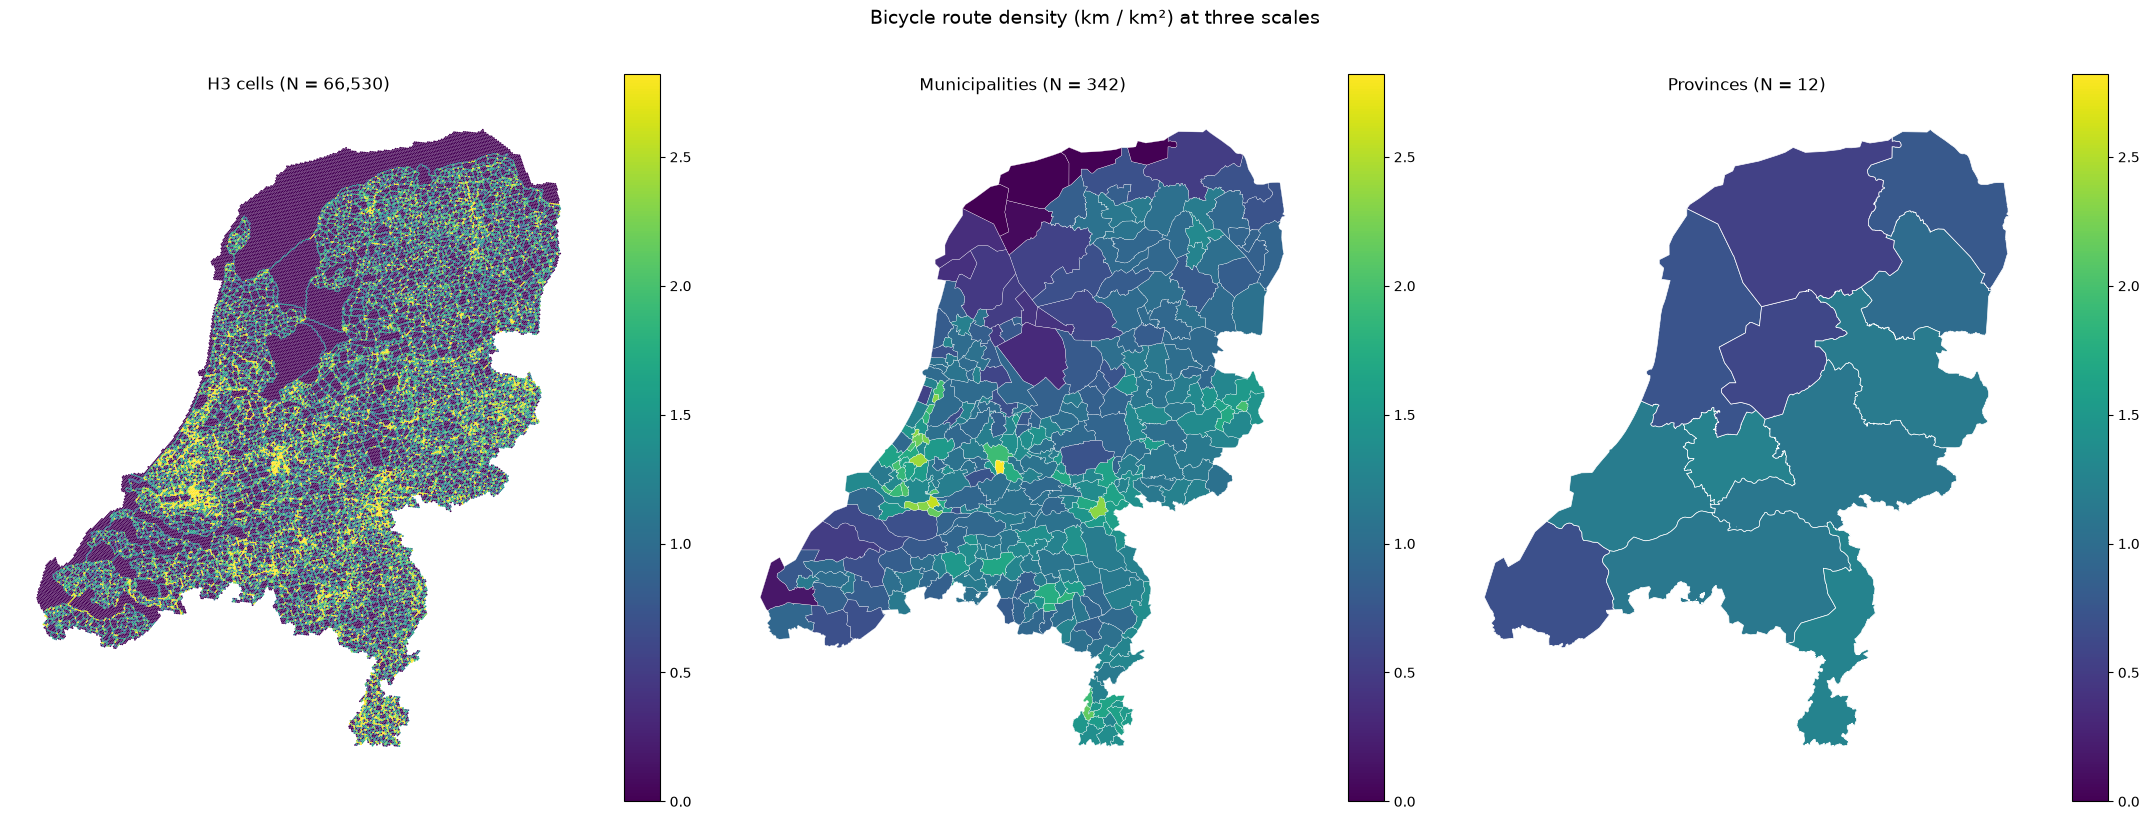

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))

vmin = 0
vmax = max(
    maup_municipality_gdf['bicycle_route_density_km_per_km2'].quantile(0.95),
    maup_h3_gdf['bicycle_route_density_km_per_km2'].quantile(0.95),
)

maup_h3_gdf.plot(
    column='bicycle_route_density_km_per_km2',
    cmap='viridis', vmin=vmin, vmax=vmax,
    legend=True, ax=axes[0], edgecolor=None
)
axes[0].set_title(f'H3 cells (N = {len(maup_h3_gdf):,})')
axes[0].axis('off')

maup_municipality_gdf.plot(
    column='bicycle_route_density_km_per_km2',
    cmap='viridis', vmin=vmin, vmax=vmax,
    legend=True, ax=axes[1], edgecolor='white', linewidth=0.2
)
axes[1].set_title(f'Municipalities (N = {len(maup_municipality_gdf):,})')
axes[1].axis('off')

maup_province_gdf.plot(
    column='bicycle_route_density_km_per_km2',
    cmap='viridis', vmin=vmin, vmax=vmax,
    legend=True, ax=axes[2], edgecolor='white', linewidth=0.5
)
axes[2].set_title(f'Provinces (N = {len(maup_province_gdf):,})')
axes[2].axis('off')

fig.suptitle('Bicycle route density (km / km²) at three scales', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 2.3 Spatial autocorrelation across scales

Moran's I is computed for `bicycle_route_density_km_per_km2` at each spatial level. Queen contiguity is used for municipalities and provinces (irregular polygons share boundaries cleanly). KNN with k=6 is used for H3 because each H3 cell has exactly six neighbours; this is also computationally tractable for the ~66k cell grid where full Queen contiguity is expensive to build.

Moran's I typically rises with scale on a spatially clustered phenomenon (coarse units smooth out local variation, leaving the larger-scale clustering signal). A monotone increase from H3 → municipality → province is the textbook MAUP signature.

In [7]:
def compute_moran(gdf, metric, weight_type='Queen', k=6, permutations=999):
    valid = gdf.dropna(subset=[metric]).reset_index(drop=True)

    if weight_type == 'Queen':
        w = libpysal.weights.Queen.from_dataframe(valid)
    elif weight_type == 'KNN':
        w = libpysal.weights.KNN.from_dataframe(valid, k=k)
    else:
        raise ValueError(f"Unknown weight_type: {weight_type}")

    w.transform = 'r'
    m = Moran(valid[metric].values, w, permutations=permutations)

    return {
        'I': m.I,
        'E[I]': m.EI,
        'z_norm': m.z_norm,
        'p_norm': m.p_norm,
        'p_sim': m.p_sim,
    }


moran_results = pd.DataFrame([
    {'unit': 'H3 (KNN, k=6)',          'n': len(maup_h3_gdf),
     **compute_moran(maup_h3_gdf,           'bicycle_route_density_km_per_km2', 'KNN', k=6)},
    {'unit': 'Municipality (Queen)',   'n': len(maup_municipality_gdf),
     **compute_moran(maup_municipality_gdf, 'bicycle_route_density_km_per_km2', 'Queen')},
    {'unit': 'Province (Queen)',       'n': len(maup_province_gdf),
     **compute_moran(maup_province_gdf,     'bicycle_route_density_km_per_km2', 'Queen')},
])

display(moran_results.set_index('unit').round(4))

/tmp/ipykernel_946/3551707740.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(valid)
/tmp/ipykernel_946/3551707740.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(valid)


,n,I,E[I],z_norm,p_norm,p_sim
unit,,,,,,
"H3 (KNN, k=6)",66530,0.3076,-0.0000,137.6864,0.0000,0.001
Municipality (Queen),342,0.4956,-0.0029,14.8297,0.0000,0.001
Province (Queen),12,0.1116,-0.0909,1.1619,0.2453,0.153


---

## 3. Zoning effect: H3 aggregated to municipality vs native municipality

Two ways to obtain a per-municipality density figure are compared:

- **Native**: `bicycle_route_density_km_per_km2` from `07_bicycle_route_extent_metrics`, computed directly from ways clipped to municipal boundaries (stage 06).
- **H3-aggregated**: for each municipality, an area-weighted average of the bicycle-route density of H3 cells whose centroid falls within the municipality.

Both approaches use the same underlying ways. Differences arise entirely from the choice of boundary system used for the initial spatial join. High convergence (Spearman ρ near 1) means the municipality-level result is robust to that choice; divergence localises municipalities where administrative and hexagonal boundary systems disagree.

### 3.1 Aggregate H3 metrics to municipality level

In [8]:
h3_centroids = maup_h3_gdf[[
    'h3_index',
    'bicycle_route_density_km_per_km2',
    'non_bicycle_route_density_km_per_km2',
    'area_km2',
    'population',
]].copy()
h3_centroids['point'] = maup_h3_gdf.geometry.centroid

h3_centroids_pts = gpd.GeoDataFrame(
    h3_centroids.drop(columns=['point']),
    geometry=h3_centroids['point'],
    crs='EPSG:4326'
)

h3_with_municipality = gpd.sjoin(
    h3_centroids_pts,
    maup_municipality_gdf[['municipality_code', 'municipality_name', 'geometry']],
    how='left',
    predicate='within'
).dropna(subset=['municipality_code'])


def area_weighted_density(g):
    total_area = g['area_km2'].sum()
    if total_area == 0:
        return pd.Series({
            'bicycle_route_density_aggregated_from_h3':     0.0,
            'non_bicycle_route_density_aggregated_from_h3': 0.0,
            'n_h3_cells_in_municipality':                   len(g),
            'h3_covered_area_km2':                          0.0,
        })

    return pd.Series({
        'bicycle_route_density_aggregated_from_h3':
            (g['bicycle_route_density_km_per_km2'] * g['area_km2']).sum() / total_area,
        'non_bicycle_route_density_aggregated_from_h3':
            (g['non_bicycle_route_density_km_per_km2'] * g['area_km2']).sum() / total_area,
        'n_h3_cells_in_municipality': len(g),
        'h3_covered_area_km2':        total_area,
    })


h3_aggregated_to_municipality = (
    h3_with_municipality
    .groupby('municipality_code')
    .apply(area_weighted_density, include_groups=False)
    .reset_index()
)

zoning_comparison = maup_municipality_gdf[[
    'municipality_code', 'municipality_name', 'geometry',
    'area_km2',
    'bicycle_route_density_km_per_km2',
    'non_bicycle_route_density_km_per_km2',
]].merge(h3_aggregated_to_municipality, on='municipality_code', how='left')

zoning_comparison['bicycle_density_diff_abs'] = (
    zoning_comparison['bicycle_route_density_km_per_km2']
    - zoning_comparison['bicycle_route_density_aggregated_from_h3']
)
zoning_comparison['bicycle_density_diff_pct'] = (
    zoning_comparison['bicycle_density_diff_abs']
    / zoning_comparison['bicycle_route_density_km_per_km2'].replace(0, np.nan)
) * 100

zoning_comparison_gdf = gpd.GeoDataFrame(zoning_comparison, geometry='geometry', crs='EPSG:4326')

display(zoning_comparison[[
    'municipality_name',
    'bicycle_route_density_km_per_km2',
    'bicycle_route_density_aggregated_from_h3',
    'bicycle_density_diff_abs',
    'bicycle_density_diff_pct',
    'n_h3_cells_in_municipality',
]].sort_values('bicycle_density_diff_pct', key=lambda s: s.abs(), ascending=False).head(15).round(3))

/tmp/ipykernel_946/53359060.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  h3_centroids['point'] = maup_h3_gdf.geometry.centroid


,municipality_name,bicycle_route_density_km_per_km2,bicycle_route_density_aggregated_from_h3,bicycle_density_diff_abs,bicycle_density_diff_pct,n_h3_cells_in_municipality
222,Aalsmeer,0.660,0.865,-0.205,-31.007,51.0
60,Krimpen aan den IJssel,2.048,1.505,0.543,26.511,12.0
141,Gouda,1.387,1.738,-0.351,-25.288,30.0
58,Hendrik-Ido-Ambacht,1.305,1.564,-0.259,-19.824,20.0
54,Landsmeer,1.236,1.006,0.230,18.597,43.0
186,Waddinxveen,0.922,1.092,-0.170,-18.418,49.0
254,Huizen,1.039,1.227,-0.188,-18.061,38.0
109,Harlingen,0.072,0.085,-0.013,-17.515,632.0
148,Scherpenzeel,1.164,1.358,-0.194,-16.632,23.0
17,Gorinchem,1.225,1.421,-0.196,-16.033,38.0


In [9]:
valid = zoning_comparison.dropna(subset=[
    'bicycle_route_density_km_per_km2',
    'bicycle_route_density_aggregated_from_h3',
])

spearman_rho, spearman_p = spearmanr(
    valid['bicycle_route_density_km_per_km2'],
    valid['bicycle_route_density_aggregated_from_h3'],
)
pearson_r, pearson_p = pearsonr(
    valid['bicycle_route_density_km_per_km2'],
    valid['bicycle_route_density_aggregated_from_h3'],
)

print(f"N municipalities compared: {len(valid)} of {len(zoning_comparison)}")
print()
print(f"Spearman's ρ : {spearman_rho:.4f}  (p = {spearman_p:.3g})")
print(f"Pearson's r  : {pearson_r:.4f}  (p = {pearson_p:.3g})")
print()
print("Absolute difference (native - H3-aggregated) [km/km²]:")
display(valid['bicycle_density_diff_abs'].describe().round(3))
print("\nPercentage difference (native - H3-aggregated) [%]:")
display(valid['bicycle_density_diff_pct'].describe().round(2))

N municipalities compared: 342 of 342

Spearman's ρ : 0.9839  (p = 3.8e-256)
Pearson's r  : 0.9864  (p = 6.95e-269)

Absolute difference (native - H3-aggregated) [km/km²]:


count    342.000
mean      -0.003
std        0.070
min       -0.351
25%       -0.024
50%       -0.002
75%        0.018
max        0.543
Name: bicycle_density_diff_abs, dtype: float64


Percentage difference (native - H3-aggregated) [%]:


count    338.00
mean      -0.54
std        5.34
min      -31.01
25%       -2.30
50%       -0.30
75%        1.77
max       26.51
Name: bicycle_density_diff_pct, dtype: float64

### 3.3 Residual map

Choropleth of the percentage difference between the native-municipality density and the H3-aggregated density. Centred-diverging colour ramp: blue means the native value is *lower* than the H3-aggregated value (the administrative boundary diluted the local concentration); red means the native value is *higher* (the administrative boundary concentrated it).

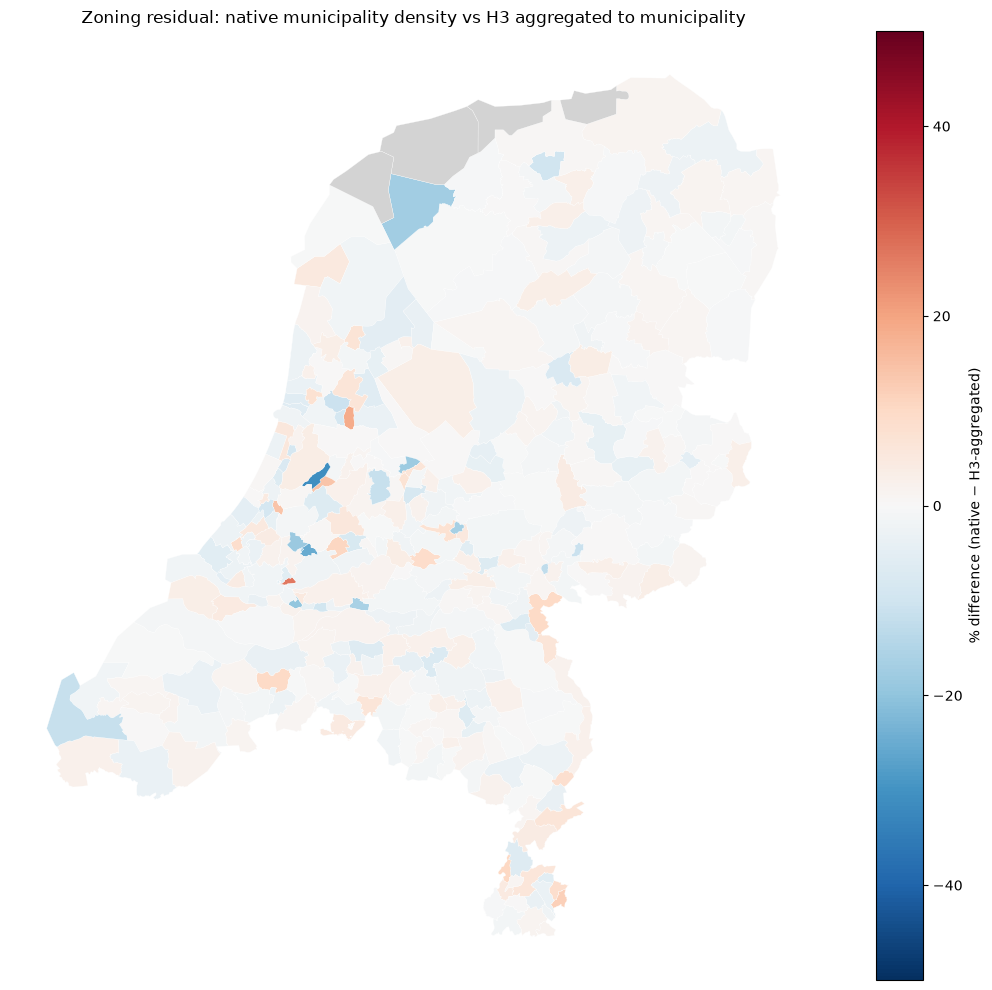

In [10]:
fig, ax = plt.subplots(figsize=(12, 10))

zoning_comparison_gdf.plot(
    column='bicycle_density_diff_pct',
    cmap='RdBu_r',
    vmin=-50, vmax=50,
    legend=True,
    ax=ax,
    edgecolor='white',
    linewidth=0.2,
    missing_kwds={'color': 'lightgrey'},
    legend_kwds={'label': '% difference (native − H3-aggregated)'}
)
ax.set_title('Zoning residual: native municipality density vs H3 aggregated to municipality')
ax.axis('off')
plt.tight_layout()
plt.show()

## 4. MAUP sensitivity of classifiability

The thesis-headline figure (52.2% of designated route facility is classifiable, 47.3% unclassifiable, 0.5% excluded, thesis §"Results") is `pct_classifiable` at the national level: `classifiable_facility_km / total_facility_km` summed across all spatial units. The MAUP question here is whether the per-spatial-unit distribution of this same ratio is robust to the choice of spatial unit, since the urban–rural gradient analysis and the LISA clusters in the thesis Results are built from per-municipality `pct_classifiable` values.

`pct_classifiable` is a bounded ratio in [0, 100]. The same caveat that applies to all ratios at fine grain applies here: an H3 cell containing a single side-row of facility will report `pct_classifiable = 0` or `100` and nothing in between, so the H3 distribution is expected to be more bimodal than the municipality or province distributions.

The metric is derived on the fly below from the `classifiable_facility_km` and `total_facility_km` columns already present in the infrastructure metrics tables.

In [14]:
for gdf in [
    bicycle_route_infrastructure_metrics_by_municipality_gdf,
    bicycle_route_infrastructure_metrics_by_province_gdf,
    bicycle_route_infrastructure_metrics_by_h3_cell_gdf,
]:
    gdf['pct_classifiable'] = (
        gdf['classifiable_facility_km']
        / gdf['total_facility_km'].replace(0, np.nan)
        * 100
    ).round(2)

    gdf['pct_unclassifiable'] = (
        (gdf['mixed_traffic_uncertain_facility_km'] + gdf['uncertain_facility_km'])
        / gdf['total_facility_km'].replace(0, np.nan)
        * 100
    ).round(2)

### 4.1 Distribution comparison

In [19]:
infra_scale_comparison_classifiable = pd.DataFrame([
    distribution_summary(bicycle_route_infrastructure_metrics_by_h3_cell_gdf,      'pct_classifiable', 'H3'),
    distribution_summary(bicycle_route_infrastructure_metrics_by_municipality_gdf, 'pct_classifiable', 'Municipality'),
    distribution_summary(bicycle_route_infrastructure_metrics_by_province_gdf,     'pct_classifiable', 'Province'),
])

infra_scale_comparison_unclassifiable = pd.DataFrame([
    distribution_summary(bicycle_route_infrastructure_metrics_by_h3_cell_gdf,      'pct_unclassifiable', 'H3'),
    distribution_summary(bicycle_route_infrastructure_metrics_by_municipality_gdf, 'pct_unclassifiable', 'Municipality'),
    distribution_summary(bicycle_route_infrastructure_metrics_by_province_gdf,     'pct_unclassifiable', 'Province'),
])

print("pct_classifiable across scales:")
display(infra_scale_comparison_classifiable.set_index('unit').round(3))

print("\n pct_unclassifiable across scales:")
display(infra_scale_comparison_unclassifiable.set_index('unit').round(3))

pct_classifiable across scales:


,n,mean,median,std,cv,min,p25,p75,max,iqr
unit,,,,,,,,,,
H3,38985,46.864,45.500,41.946,0.895,0.00,0.000,97.02,102.56,97.020
Municipality,338,53.977,53.965,15.641,0.290,14.72,42.112,65.58,89.35,23.468
Province,12,51.596,52.210,10.166,0.197,34.54,44.498,57.85,70.28,13.352



 pct_unclassifiable across scales:


,n,mean,median,std,cv,min,p25,p75,max,iqr
unit,,,,,,,,,,
H3,38985,52.567,53.150,41.984,0.799,0.00,1.990,100.000,100.14,98.010
Municipality,338,45.398,45.415,15.683,0.345,10.65,33.832,57.185,85.16,23.353
Province,12,47.835,47.685,10.405,0.218,28.24,41.645,55.340,64.00,13.695


### 4.2 Spatial autocorrelation

Moran's I for `pct_classifiable` at each spatial level. Spatial units with `NaN` (zero total facility km, i.e. no designated route facility at all in the unit) are dropped before computing weights, since `pct_classifiable` is undefined there.

In [18]:
moran_classifiable_results = pd.DataFrame([
    {'unit': 'H3 (KNN, k=6)',        'n': bicycle_route_infrastructure_metrics_by_h3_cell_gdf['pct_classifiable'].notna().sum(),
     **compute_moran(bicycle_route_infrastructure_metrics_by_h3_cell_gdf,      'pct_classifiable', 'KNN', k=6)},
    {'unit': 'Municipality (Queen)', 'n': bicycle_route_infrastructure_metrics_by_municipality_gdf['pct_classifiable'].notna().sum(),
     **compute_moran(bicycle_route_infrastructure_metrics_by_municipality_gdf, 'pct_classifiable', 'Queen')},
    {'unit': 'Province (Queen)',     'n': bicycle_route_infrastructure_metrics_by_province_gdf['pct_classifiable'].notna().sum(),
     **compute_moran(bicycle_route_infrastructure_metrics_by_province_gdf,     'pct_classifiable', 'Queen')},
])

display(moran_classifiable_results.set_index('unit').round(4))

/home/vbo226/.local/lib/python3.11/site-packages/libpysal/weights/distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
/tmp/ipykernel_946/3551707740.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(valid)
/tmp/ipykernel_946/3551707740.py:5: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = libpysal.weights.Queen.from_dataframe(valid)


,n,I,E[I],z_norm,p_norm,p_sim
unit,,,,,,
"H3 (KNN, k=6)",38985,0.4086,-0.0000,144.0277,0.0000,0.001
Municipality (Queen),338,0.4362,-0.0030,13.0009,0.0000,0.001
Province (Queen),12,-0.0973,-0.0909,-0.0368,0.9706,0.495


### Overall verdict

The municipality is a defensible unit of analysis for the headline thesis results (§3.4.6). Four pieces of evidence support this:

1. **Zoning robustness of the extent metric.** Native municipality density and H3-aggregated municipality density agree at Spearman's ρ = 0.984 across all 342 municipalities, with a typical municipality moving less than ±3% between the two boundary systems. The headline rank ordering of municipalities by bicycle-route density is essentially independent of the choice of boundary system.
2. **Statistically significant spatial signal at the municipality scale.** Moran's I = 0.50 (p < 0.001) for bicycle-route density and I = 0.44 (p < 0.001) for `pct_classifiable` at the municipality level confirm that there is a coherent spatial pattern to detect at the headline unit, and that the municipality is fine enough to detect it. The province scale is too coarse to carry a useful Moran's I (N = 12, both metrics non-significant); the H3 scale carries the highest variance but at the cost of substantial small-N noise per cell.
3. **Cross-scale convergence of `pct_classifiable`.** The unweighted means at municipality (53.98%) and province (51.60%) are within 2.4 percentage points of each other and within 1.8 of the length-weighted national headline (52.2%). The thesis-headline classifiability figure is not an artefact of any particular spatial unit; it is what the data report at every scale that has the statistical power to support an aggregate.
4. **Moran's I on `pct_classifiable` is stable across H3 and municipality** (0.41 vs. 0.44), indicating that the spatial clustering of classifiability is driven by between-municipality variation rather than within-municipality variation. This directly supports the thesis's framing of the urban–rural gradient and LISA clusters as municipality-level phenomena rather than artefacts of administrative boundary choice.

The MAUP behaviour does, however, sharpen one qualification that should be carried into the discussion. The H3 grain is unsuitable for direct inference on classifiability: at the resolution-8 cell size, most cells contain too few side-rows for `pct_classifiable` to be a meaningful ratio (median IQR spans 0% to 97%, bimodal at the extremes). Conclusions framed at the municipality level are well-supported; conclusions framed at the H3 grain should be treated as descriptive rather than inferential, and conclusions framed at the level of an individual small municipality should be treated with the same caution the zoning residual map (§3.3) suggests, particularly for the seven outlier municipalities identified above.